In [1]:
# reload modules before execution (for the changing code in Src)
%load_ext autoreload
%autoreload 2

In [33]:
from pathlib import Path
import sys

SRC_FOLDER = Path(Path.cwd().parent / "src").resolve()
sys.path.append(str(SRC_FOLDER))
import preparation

UTILS_FOLDER = Path(Path().cwd().parent.parent / "rabbit_holes" / "src").resolve()
sys.path.append(str(UTILS_FOLDER))
import plotting_tools

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
PROCESSED_DATA_FOLDER = Path("../Data/Processed/").resolve()
bicliques_fn = "bicliques_wave_5.csv"
data_fn = "base_values_wave_5.parquet"
data, complete_data = preparation.import_bicliques(PROCESSED_DATA_FOLDER / data_fn, PROCESSED_DATA_FOLDER / bicliques_fn)
labels = pd.read_csv(PROCESSED_DATA_FOLDER / "clusters_4.csv", index_col=0)

In [4]:
subm_most_rows = complete_data[0]

# Cluster visualization

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
X = StandardScaler().fit_transform(complete_data[0])
X_PCA = PCA().fit_transform(X)
X_tSNE = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        #random_state=42
    ).fit_transform(X)

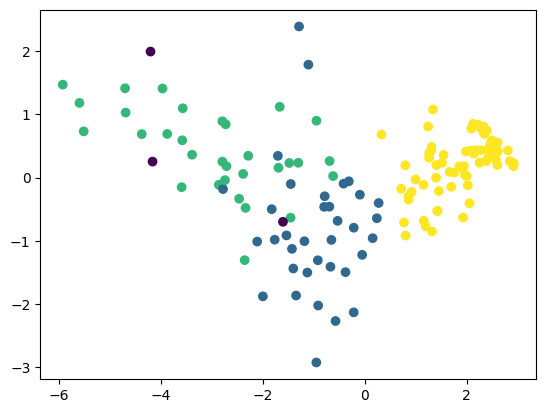

In [6]:
plt.scatter(X_PCA[:, 0], X_PCA[:, 1], c=labels['final'])

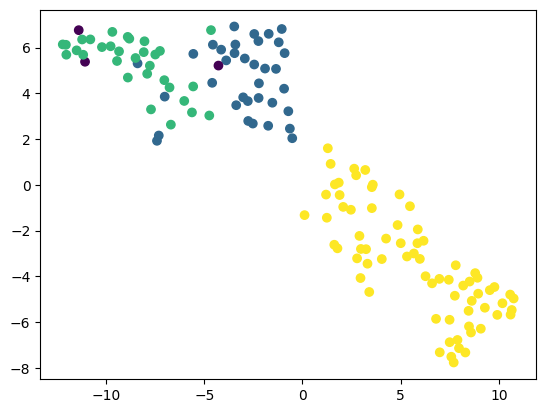

In [7]:
plt.scatter(X_tSNE[:, 0], X_tSNE[:, 1], c=labels['final'])

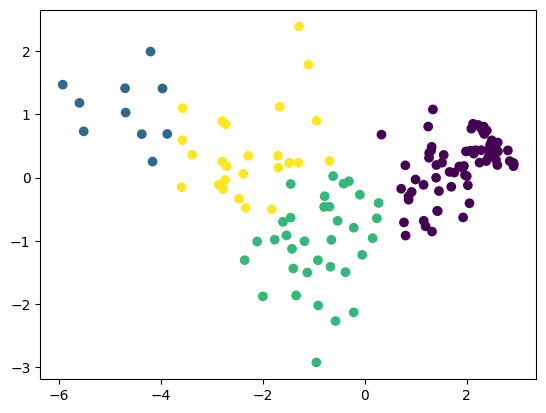

In [8]:
plt.scatter(X_PCA[:, 0], X_PCA[:, 1], c=labels["0"])

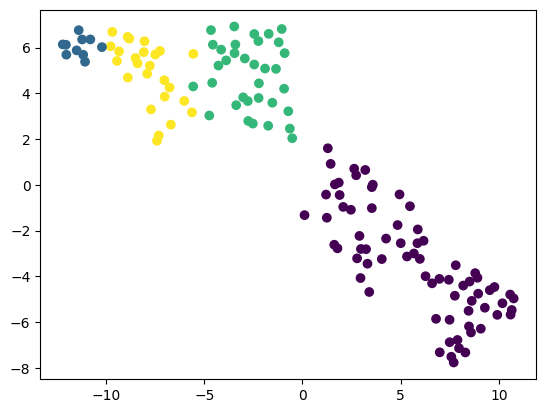

In [9]:
plt.scatter(X_tSNE[:, 0], X_tSNE[:, 1], c=labels['0'])

# Cluster profiling

In [10]:
final_cluster_profiles = (
    data.assign(final=labels['final'])
    .groupby(by='final')
    .agg(["mean", "median", "std"])
)

In [11]:
final_cluster_profiles.loc[:, subm_most_rows.columns]

series_id account.t.d                             con1                        \
                 mean     median        std       mean     median        std   
final                                                                          
0           42.102902  48.830277  12.840957  66.311188  62.935250  10.421058   
1           49.897373  46.457314  14.849195  86.342177  86.358704   6.870838   
2           54.466349  55.576039  17.656348  76.067322  78.978505  12.684291   
3           88.959253  91.061004   9.830669  95.035452  95.249153   2.994475   

series_id      con9a                       fiaccount.t.d             \
                mean     median        std          mean     median   
final                                                                 
0          39.231238  32.412080  27.016305     33.429137  33.535746   
1          68.699312  69.277685  11.580744     46.894221  43.378976   
2          36.183791  37.230989  15.613285     27.015176  21.944173   
3          85.810464  86.640704   6.783188     88.625785  91.061004   

series_id              fin2.t.d                         internet             \
                 std       mean     median        std       mean     median   
final                                                                         
0          15.094852  14.496198  12.803661   5.003026  40.059700  35.678699   
1          15.156281  30.330318  29.948638  12.086777  74.065567  77.522886   
2          14.144252  13.701732  10.167417  12.071317  39.432541  38.226973   
3          10.137216  80.663380  81.775160  13.678413  89.827352  90.227809   

series_id             
                 std  
final                 
0          28.711739  
1          13.473911  
2          15.324412  
3           6.207893

In [12]:
most_rows_cluster_profiles = (
    subm_most_rows.assign(labels=labels["0"])
    .groupby(by='labels')
    .agg(["mean", "median", "std"])
)

In [13]:
most_rows_cluster_profiles

series_id account.t.d                             con1                       \
                 mean     median        std       mean     median       std   
labels                                                                        
0           88.959253  91.061004   9.830669  95.035452  95.249153  2.994475   
1           37.110511  38.917266  14.385166  57.853210  58.493673  6.569878   
2           48.571807  48.319868  13.766125  87.392788  87.348846  5.691852   
3           61.545081  59.991116  14.150860  81.164394  81.632236  5.929941   

series_id      con9a                       fiaccount.t.d             \
                mean     median        std          mean     median   
labels                                                                
0          85.810464  86.640704   6.783188     88.625785  91.061004   
1          19.035602  19.295341   7.699895     18.376820  14.442673   
2          71.007502  69.417242   7.970424     43.511746  42.662019   
3          41.570242  44.705641  10.873028     36.635521  32.947894   

series_id              fin2.t.d                         internet             \
                 std       mean     median        std       mean     median   
labels                                                                        
0          10.137216  80.663380  81.775160  13.678413  89.827352  90.227809   
1          11.377875   6.380951   4.653570   4.465318  23.283357  23.805130   
2          12.438768  29.299092  27.821709  12.335466  77.185894  77.836183   
3          20.040306  18.792990  14.083442  13.558685  43.109150  43.714479   

series_id            
                std  
labels               
0          6.207893  
1          9.870356  
2          8.635099  
3          9.363373

# Regression

In [14]:
import statsmodels.formula.api as smf

In [15]:
def etas_ols(data, labels):
    etas = []
    
    for feature in data.columns:
        feature_data = (
            data[[feature]]
            .rename(columns={feature:"value"})
            .assign(label=labels)
            .dropna()
        )
    
        model = smf.ols(
            "value ~ C(label)",
            data=feature_data
        ).fit()
    
        eta_sq = model.rsquared
    
        etas.append({
            "feature": feature,
            "eta_2": eta_sq
        })

    return pd.DataFrame(etas)

In [16]:
etas_ols(subm_most_rows, labels["0"])

,feature,eta_2
0,account.t.d,0.731718
1,con1,0.824727
2,con9a,0.880364
3,fiaccount.t.d,0.807331
4,fin2.t.d,0.845447
5,internet,0.892667


In [17]:
etas_ols(subm_most_rows, labels["final"])

,feature,eta_2
0,account.t.d,0.673704
1,con1,0.564587
2,con9a,0.772056
3,fiaccount.t.d,0.821024
4,fin2.t.d,0.846973
5,internet,0.768382


In [24]:
feature_etas

,feature_x,eta_2_x,feature_y,eta_2_y
0,account.t.d,0.673704,account.t.d,0.731718
1,borrow.any.t.d,0.504726,borrow.any.t.d,0.432705
2,con1,0.564587,con1,0.824727
3,con10,0.042794,con10,0.029409
4,con11,0.256441,con11,0.542657
...,...,...,...,...
275,inactive.t.d,0.122867,inactive.t.d,0.012021
276,internet,0.768382,internet,0.892667
277,merchant.pay,0.651057,merchant.pay,0.668021
278,mobileaccount.t.d,0.432699,mobileaccount.t.d,0.230409


In [25]:
feature_etas = etas_ols(data, labels["final"])
feature_etas.rename(columns={"eta_2": "eta_2_final"}, inplace=True)
feature_etas = pd.merge(feature_etas, etas_ols(data, labels["0"]), left_index=True, right_index=True)
feature_etas["delta_eta_2"] = feature_etas["eta_2"] - feature_etas["eta_2_final"]

C:\Users\mbr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\mbr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\mbr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\mbr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [32]:
feature_etas["delta_eta_2"].describe()

count    278.000000
mean       0.009694
std        0.115885
min       -0.336444
25%       -0.037950
50%        0.004386
75%        0.042365
max        0.453614
Name: delta_eta_2, dtype: float64

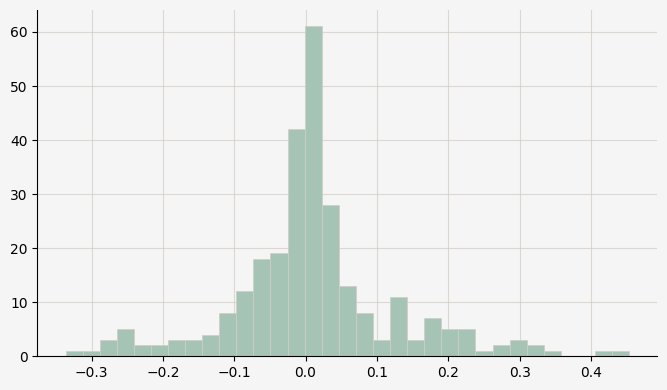

In [34]:
plotting_tools.pretty_histogram(feature_etas["delta_eta_2"])